<a href="https://colab.research.google.com/github/SurajChauhan4432/Data-Science-Assignment-1/blob/main/International_T20_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<b> INTRODUCTION TO DATA SCIENCE - ASSIGNMENT 1</b>


##<b> The International Cricket Council (ICC) is the world governing body of cricket. It was founded as the Imperial Cricket Conference in 1909 by representatives from Australia, England and South Africa. It was renamed as the International Cricket Conference in 1965, and took up its current name in 1989. It organises world championship events such as Cricket World Cup, Women's Cricket World Cup, ICC T20 World Cup, ICC Women's T20 World Cup, ICC Champions Trophy and Under-19 Cricket World Cup.</b>

<br>

## <b> You recently got a lucky break in the field of Data Science. You got a job of Data Scientist at ICC. You are part of the Analytics Team which is involved in pre-match analyses, live-match analyses and post-match analyses. </b>

<br>

## <b>This data consists of 1417 T20 matches. Each row corresponds to a single T20 match. As a data scientist, you have to first explore the data and check its sanity. </b>

<br>

## <u><b>Further you are required to do some analyses :</b></u>
* ### Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date
* ### Find out the top three venues which hosted the greatest number of matches.
* ### Find out the pair of cricket teams who played the most number of T20 matches against each other.
* ### Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.
* ### Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.




In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv('International_T20_Data.csv')

## <u><b>BASIC OVERVIEW USING PANDAS: SHAPE AND DATA TYPES</b></u>




In [ ]:
df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,meta.data_version,meta.revision,info.outcome.by.wickets,info.overs,info.outcome.by.runs,info.match_type_number,info.neutral_venue
count,1.417000e+03,1417.000000,651.000000,1417.000000,721.000000,684.000000,328.0
mean,9.000000e-01,1.370501,6.476190,20.063514,39.088766,748.774854,1.0
std,5.108829e-15,0.575198,1.987802,1.379399,33.385757,190.050264,0.0
min,9.000000e-01,1.000000,1.000000,20.000000,1.000000,380.000000,1.0
25%,9.000000e-01,1.000000,5.000000,20.000000,13.000000,627.000000,1.0
50%,9.000000e-01,1.000000,7.000000,20.000000,30.000000,746.500000,1.0
75%,9.000000e-01,2.000000,8.000000,20.000000,56.000000,883.250000,1.0
max,9.000000e-01,5.000000,10.000000,50.000000,249.000000,1104.000000,1.0


In [ ]:
# 1. Check the dimensions of the dataset (rows, columns)
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# 2. Get a concise summary of the dataframe
# This shows the data types (int, float, object/string) and non-null counts
print("\n--- Data Types and Non-Null Counts ---")
df.info()

The dataset contains 1417 rows and 27 columns.

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   innings                      1417 non-null   object 
 1   meta.data_version            1417 non-null   float64
 2   meta.created                 1417 non-null   object 
 3   meta.revision                1417 non-null   int64  
 4   info.dates                   1417 non-null   object 
 5   info.gender                  1417 non-null   object 
 6   info.match_type              1417 non-null   object 
 7   info.outcome.by.wickets      651 non-null    float64
 8   info.outcome.winner          1372 non-null   object 
 9   info.overs                   1417 non-null   int64  
 10  info.player_of_match         1255 non-null   object 
 11  info.teams                   1417 non-null   ob

## <u><b>IDENTIFYING MISSING VALUES (NaNs)</b></u>




In [ ]:
# 1. Calculate the total missing values in each column
missing_data = df.isnull().sum()

# 2. Filter to show only columns that actually have missing values
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Columns with missing values:")
if missing_data.empty:
    print("No missing values found! The data is perfectly clean.")
else:
    print(missing_data)

    # Optional: Calculate the percentage of missing data for context
    print("\n--- Percentage of Missing Data ---")
    missing_percentage = (missing_data / len(df)) * 100
    print(missing_percentage.round(2).astype(str) + '%')

Columns with missing values:
info.supersubs.South Africa    1416
info.supersubs.New Zealand     1416
info.outcome.bowl_out          1415
info.bowl_out                  1415
info.outcome.eliminator        1401
info.outcome.result            1372
info.outcome.method            1366
info.neutral_venue             1089
info.outcome.by.wickets         766
info.match_type_number          733
info.outcome.by.runs            696
info.city                       189
info.player_of_match            162
info.outcome.winner              45
info.umpires                     22
dtype: int64

--- Percentage of Missing Data ---
info.supersubs.South Africa    99.93%
info.supersubs.New Zealand     99.93%
info.outcome.bowl_out          99.86%
info.bowl_out                  99.86%
info.outcome.eliminator        98.87%
info.outcome.result            96.82%
info.outcome.method             96.4%
info.neutral_venue             76.85%
info.outcome.by.wickets        54.06%
info.match_type_number         51.73%
in

## <u><b>CHECKING FOR DUPLICATE ROWS</b></u>




In [ ]:
# Check for exact duplicate rows across all columns
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows found: {duplicate_count}")

# If duplicates exist, you can view them using:
df[df.duplicated(keep=False)]

# And you can drop them using:
# df.drop_duplicates(inplace=True)

Number of duplicate rows found: 0


,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out


## <u><b>EXPLORING CATEGORICAL DATA (SANITY CHECKS)</b></u>




In [ ]:
# Check unique values in the 'outcome.result' column
# This tells us the different ways a match can end in this dataset
if 'info.outcome.result' in df.columns:
    print("Types of Match Results:")
    print(df['info.outcome.result'].value_counts(dropna=False))

# Check unique values in 'gender' to ensure this is purely men's or women's T20, or a mix
if 'info.gender' in df.columns:
    print("\nGender Categories:")
    print(df['info.gender'].value_counts())

Types of Match Results:
info.outcome.result
NaN          1372
no result      26
tie            19
Name: count, dtype: int64

Gender Categories:
info.gender
male      951
female    466
Name: count, dtype: int64


## <u><b>Counting how many times each venue hosted a match</b></u>




In [ ]:
venue_counts = df['info.venue'].value_counts()
print(venue_counts)

info.venue
Dubai International Cricket Stadium      62
Sheikh Zayed Stadium                     41
Shere Bangla National Stadium            39
R Premadasa Stadium                      35
Kinrara Academy Oval                     32
                                         ..
St Lawrence Ground                        1
Clontarf Cricket Club Ground              1
Mercantile Cricket Association Ground     1
Boland Park                               1
National Cricket Stadium, St George's     1
Name: count, Length: 194, dtype: int64


## <u><b>MATPLOTLIB - BASIC DATA VISULIZATION</b></u>




## <b>1. Setting the canvas size for the plot (making it bigger)</b></u>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

## <b>2. HIST: Distribution of runs to see the most common score ranges</b>

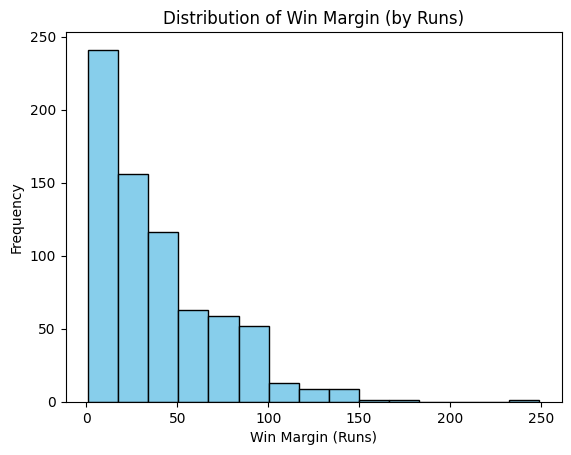

In [ ]:
plt.hist(df['info.outcome.by.runs'].dropna(), bins=15, color='skyblue', edgecolor='black')

plt.title('Distribution of Win Margin (by Runs)')

plt.xlabel('Win Margin (Runs)')

plt.ylabel('Frequency')

plt.show()

## <b>3. PIE PLOT: Win share by team</b>

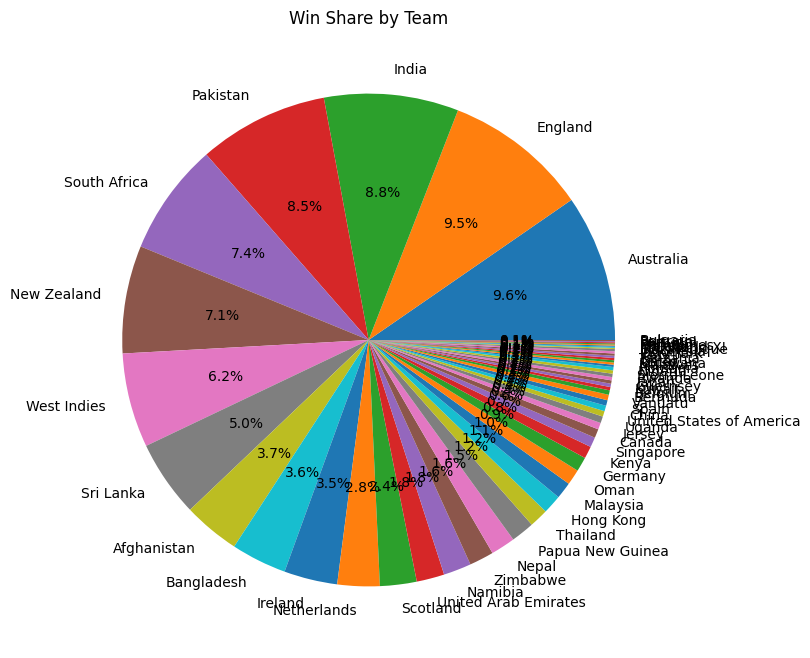

In [ ]:
wins = df['info.outcome.winner'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(wins, labels=wins.index, autopct='%1.1f%%')
plt.title('Win Share by Team')
plt.show()

## <u><b>SEABORN - Used for more attractive, advanced statistical graphics</b></u>




In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sns.set_theme(style="whitegrid")

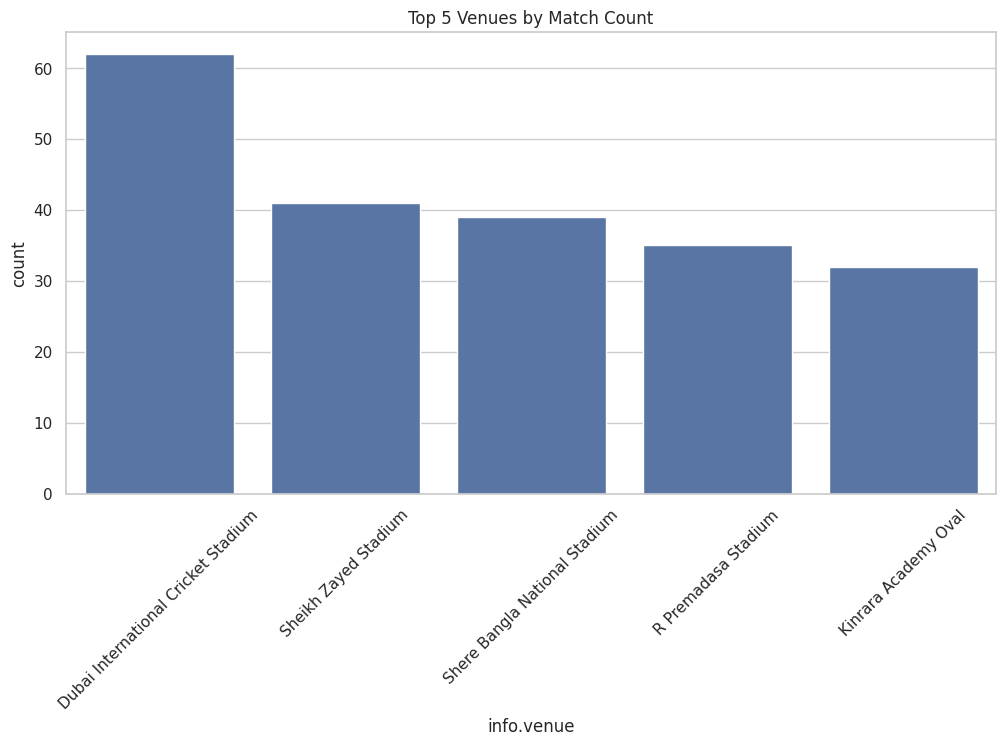

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='info.venue', order=df['info.venue'].value_counts().iloc[:5].index)
plt.title('Top 5 Venues by Match Count')
plt.xticks(rotation=45) # rotating Matplotlib labels here so they fit
plt.show()

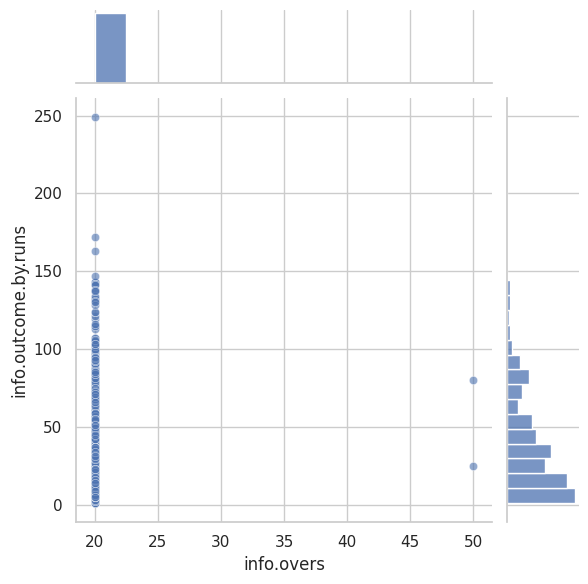

In [7]:
sns.jointplot(data=df, x='info.overs', y='info.outcome.by.runs', kind='scatter', alpha=0.6)
plt.show()

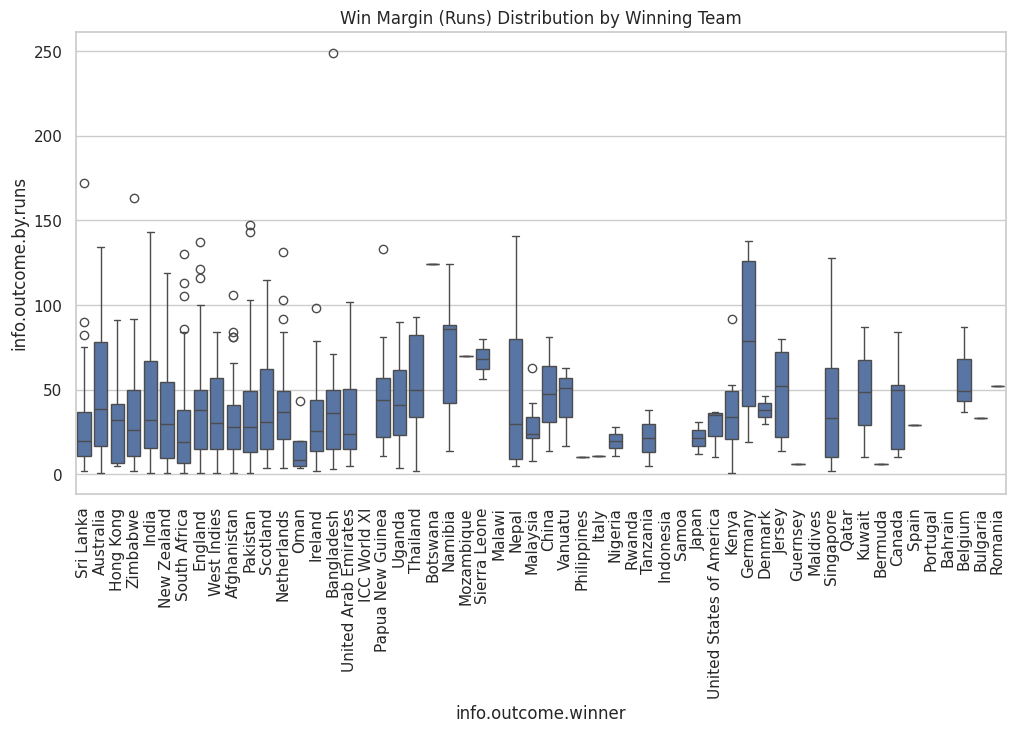

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='info.outcome.winner', y='info.outcome.by.runs')
plt.title('Win Margin (Runs) Distribution by Winning Team')
plt.xticks(rotation=90)
plt.show()

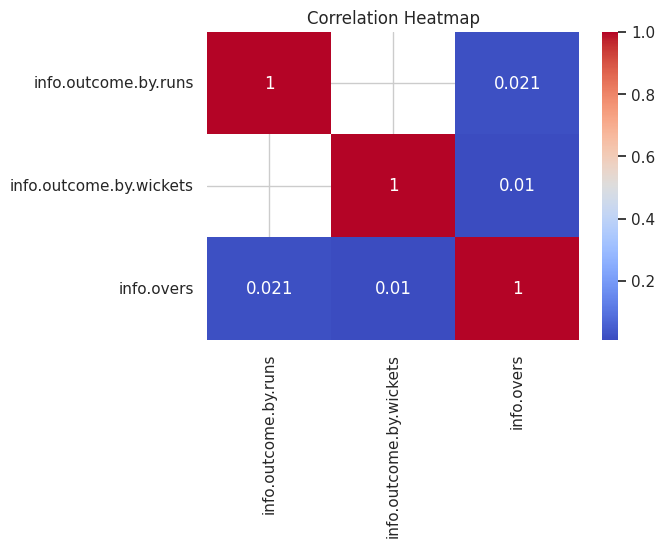

In [11]:
correlation_matrix = df[['info.outcome.by.runs', 'info.outcome.by.wickets', 'info.overs']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

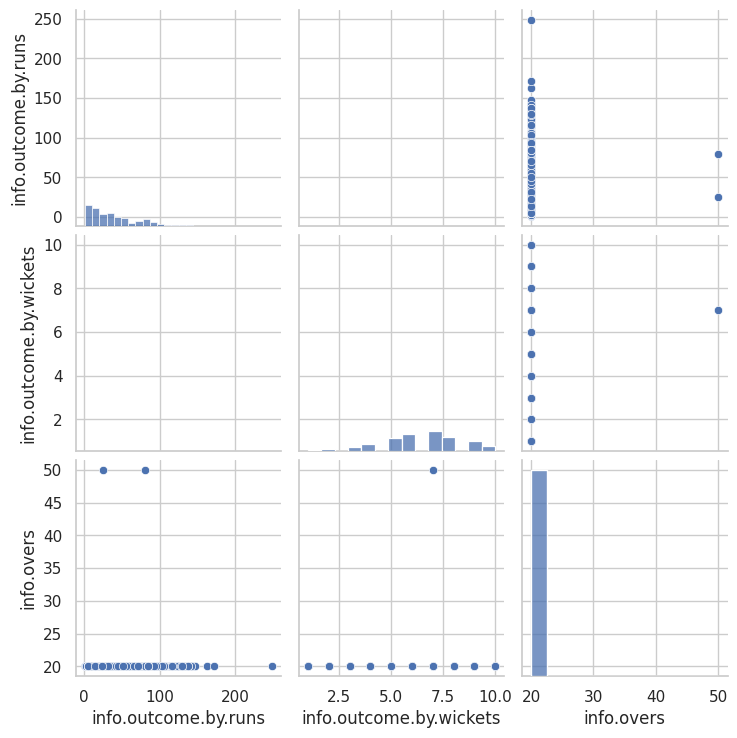

In [12]:
sns.pairplot(df[['info.outcome.by.runs', 'info.outcome.by.wickets', 'info.overs']])
plt.show()

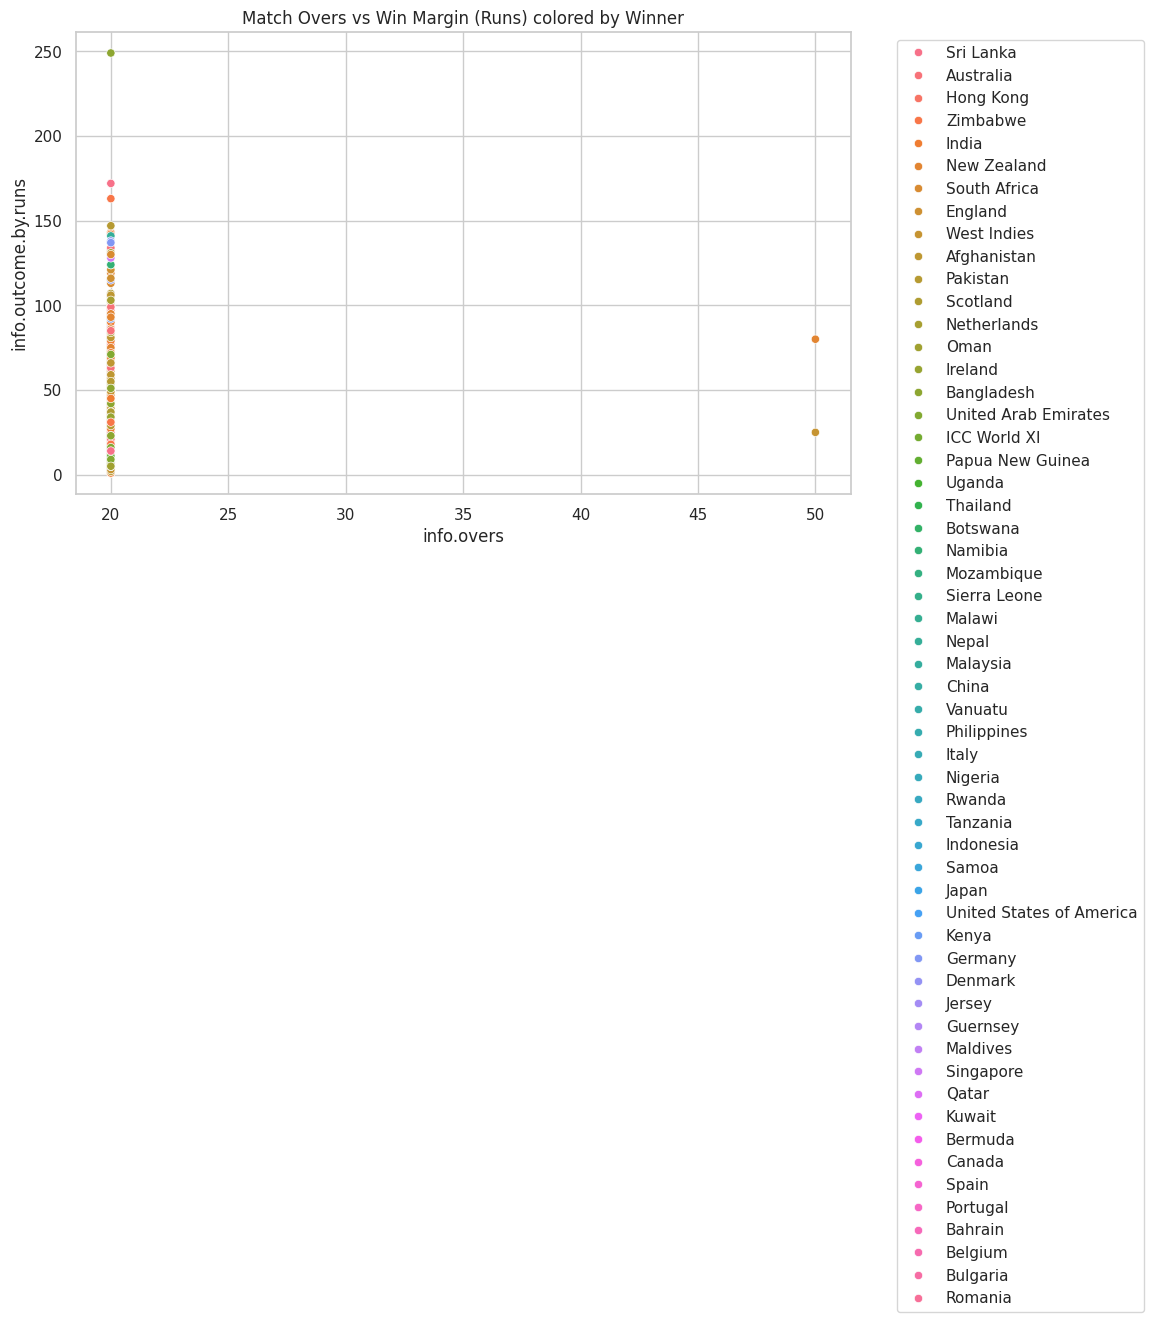

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='info.overs', y='info.outcome.by.runs', hue='info.outcome.winner')
# Moving the legend outside the plot so it doesn't cover your data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Match Overs vs Win Margin (Runs) colored by Winner')
plt.show()

## <u><b>Further you are required to do some analyses :</b></u>
* ### Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date




In [ ]:
import pandas as pd
import numpy as np
import ast # Required to safely parse string representations of lists/dicts

# 1. Automatically remove 'meta.' and 'info.' prefixes from all column names
df.columns = df.columns.str.replace(r'^(meta\.|info\.)', '', regex=True)

# 2. Rename specific columns to cleaner names
df.rename(columns={
    'created': 'created_date',
    'outcome.winner': 'winner',
    'outcome.result': 'result',
    'toss.decision': 'toss_decision',
    'toss.winner': 'toss_winner',
    'player_of_match': 'player_of_match'
}, inplace=True)

print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['innings', 'data_version', 'created_date', 'revision', 'dates', 'gender', 'match_type', 'outcome.by.wickets', 'winner', 'overs', 'player_of_match', 'teams', 'toss_decision', 'toss_winner', 'umpires', 'venue', 'city', 'outcome.by.runs', 'match_type_number', 'neutral_venue', 'outcome.method', 'result', 'outcome.eliminator', 'supersubs.New Zealand', 'supersubs.South Africa', 'bowl_out', 'outcome.bowl_out']


* ### Find out the top three venues which hosted the greatest number of matches.



In [ ]:
top_3_venues = df['venue'].value_counts().head(3)

print("Top 3 Venues by Matches Hosted:")
print(top_3_venues)

Top 3 Venues by Matches Hosted:
venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64


* ### Find out the pair of cricket teams who played the most number of T20 matches against each other.



In [ ]:
def parse_and_sort_teams(team_string):
    # Convert string like "['Team A', 'Team B']" into a real Python list
    team_list = ast.literal_eval(team_string)
    # Sort alphabetically and convert to a tuple so it can be counted
    return tuple(sorted(team_list))

# Apply the function to create a matchup column
df['matchup'] = df['teams'].apply(parse_and_sort_teams)

# Find the most frequent pair
top_matchup = df['matchup'].value_counts().head(1)

print("The pair of teams that played the most against each other:")
print(top_matchup)

The pair of teams that played the most against each other:
matchup
(Australia, England)    45
Name: count, dtype: int64


* ### Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.



In [ ]:
# 1. Convert the 'teams' string into a real list for the whole column
df['team_list'] = df['teams'].apply(ast.literal_eval)

# 2. Explode the list so each team gets its own row, then count matches played
matches_played = df.explode('team_list')['team_list'].value_counts()

# 3. Count matches won by each team
matches_won = df['winner'].value_counts()

# 4. Calculate Win Percentage (Wins / Played * 100)
win_percentage = (matches_won / matches_played) * 100

# 5. Drop NaN values (teams with no wins or no result matches) and sort
top_5_teams = win_percentage.dropna().sort_values(ascending=False).head(5)

print("Top 5 Teams by Win Percentage:")
print(top_5_teams)

Top 5 Teams by Win Percentage:
Belgium        100.000000
Spain           83.333333
Germany         76.470588
Namibia         73.529412
Afghanistan     68.000000
Name: count, dtype: float64


* ### Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.




In [ ]:
import pandas as pd
import ast
from IPython.display import display # This makes dataframes look beautiful in Colab!

def get_scorecard(innings_value):
    """
    Takes the nested innings string from a single row and returns
    two dataframes formatted like the TV broadcast scorecard.
    """
    # 1. Parse the string into a Python list/dict safely
    if isinstance(innings_value, str):
        try:
            innings_data = ast.literal_eval(innings_value)
        except (ValueError, SyntaxError):
            return None, None
    else:
        innings_data = innings_value

    scorecards = []

    # 2. Iterate over 1st and 2nd innings
    for inn in innings_data:
        inn_key = list(inn.keys())[0] # Usually '1st innings' or '2nd innings'
        deliveries = inn[inn_key]['deliveries']

        batting_stats = {}
        bowling_stats = {}

        # 3. Loop through every single ball
        for delivery in deliveries:
            ball_key = list(delivery.keys())[0]
            ball_data = delivery[ball_key]

            batsman = ball_data.get('batsman')
            bowler = ball_data.get('bowler')

            # Extract runs
            runs_bat = ball_data.get('runs', {}).get('batsman', 0)
            runs_total = ball_data.get('runs', {}).get('total', 0)
            extras = ball_data.get('extras', {})

            # --- BATTING AGGREGATIONS ---
            if batsman not in batting_stats:
                batting_stats[batsman] = {'Runs': 0, 'Balls': 0}

            batting_stats[batsman]['Runs'] += runs_bat

            # Wides don't count as a ball faced for the batsman
            if 'wides' not in extras:
                batting_stats[batsman]['Balls'] += 1

            # --- BOWLING AGGREGATIONS ---
            if bowler not in bowling_stats:
                bowling_stats[bowler] = {'Wickets': 0, 'Runs_Conceded': 0, 'Legal_Balls': 0}

            # Bowler doesn't concede byes or legbyes
            bowler_runs = runs_total
            if 'byes' in extras or 'legbyes' in extras:
                bowler_runs -= (extras.get('byes', 0) + extras.get('legbyes', 0))
            bowling_stats[bowler]['Runs_Conceded'] += bowler_runs

            # Calculate legal deliveries for overs (no wides, no no-balls)
            if 'wides' not in extras and 'noballs' not in extras:
                bowling_stats[bowler]['Legal_Balls'] += 1

            # Calculate wickets (excluding run outs)
            if 'wicket' in ball_data:
                kind = ball_data['wicket'].get('kind', '')
                if kind not in ['run out', 'retired hurt', 'obstructing the field']:
                    bowling_stats[bowler]['Wickets'] += 1

        # 4. Format the Batting DataFrame
        bat_df = pd.DataFrame.from_dict(batting_stats, orient='index').reset_index()
        bat_df.rename(columns={'index': 'Batsman'}, inplace=True)
        bat_df = bat_df.sort_values(by=['Runs', 'Balls'], ascending=[False, True]).head(4).reset_index(drop=True)

        # 5. Format the Bowling DataFrame
        bowl_df = pd.DataFrame.from_dict(bowling_stats, orient='index').reset_index()
        if not bowl_df.empty:
            bowl_df.rename(columns={'index': 'Bowler'}, inplace=True)

            # Create standard TV format: 'Wickets-Runs' and 'Overs'
            bowl_df['W-R'] = bowl_df['Wickets'].astype(str) + '-' + bowl_df['Runs_Conceded'].astype(str)
            bowl_df['Overs'] = (bowl_df['Legal_Balls'] // 6).astype(str) + '.' + (bowl_df['Legal_Balls'] % 6).astype(str)
            bowl_df['Overs'] = bowl_df['Overs'].str.replace('.0', '', regex=False) # Clean up "4.0" to just "4"

            # Sort by Wickets, then least runs conceded
            bowl_df = bowl_df.sort_values(by=['Wickets', 'Runs_Conceded'], ascending=[False, True]).head(4).reset_index(drop=True)
            bowl_df = bowl_df[['Bowler', 'W-R', 'Overs']] # Keep only the TV columns
        else:
            bowl_df = pd.DataFrame(columns=['Bowler', 'W-R', 'Overs'])

        # 6. Combine Side-by-Side
        scorecard = pd.concat([bat_df, bowl_df], axis=1)
        scorecard = scorecard.fillna('') # Clean up any NaNs if there are fewer than 4 players
        scorecards.append(scorecard)

    # Catch edge cases (e.g., match washed out before 2nd innings)
    while len(scorecards) < 2:
        scorecards.append(pd.DataFrame(columns=['Batsman', 'Runs', 'Balls', 'Bowler', 'W-R', 'Overs']))

    return scorecards[0], scorecards[1]


# =====================================================================
# EXECUTION BLOCK - This is the part that actually runs and prints it!
# =====================================================================

# Grab the innings data from the very first row (index 0) of your dataframe
sample_match_innings = df.loc[0, 'innings']

# Run the function on that data
innings_1_df, innings_2_df = get_scorecard(sample_match_innings)

# Display the output using Colab's rich display format
print("=================== 1ST INNINGS ===================")
display(innings_1_df)

print("\n=================== 2ND INNINGS ===================")
display(innings_2_df)

=================== 1ST INNINGS ===================


,Batsman,Runs,Balls,Bowler,W-R,Overs
0,AJ Finch,43,34,SL Malinga,2-29,4
1,M Klinger,38,32,DAS Gunaratne,1-11,1
2,TM Head,31,25,PADLR Sandakan,1-30,4
3,AJ Turner,18,13,JRMVB Sanjaya,1-35,3



=================== 2ND INNINGS ===================


,Batsman,Runs,Balls,Bowler,W-R,Overs
0,DAS Gunaratne,52,37,AJ Turner,2-12,2
1,EMDY Munaweera,44,29,A Zampa,2-26,4
2,N Dickwella,30,25,PJ Cummins,1-29,4
3,TAM Siriwardana,15,11,JP Faulkner,0-27,4


## <u><b>FURTHER DATA VISUALIZATION USING SEABORN AND MATPLOTLIB</b></u>




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all plots to make them look professional
sns.set_theme(style="whitegrid")

## <u><b>Visualization 1: Top 10 Venues (Horizontal Bar Chart)</b></u>




/tmp/ipykernel_759/3433257155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_venues.values, y=top_10_venues.index, palette='viridis')


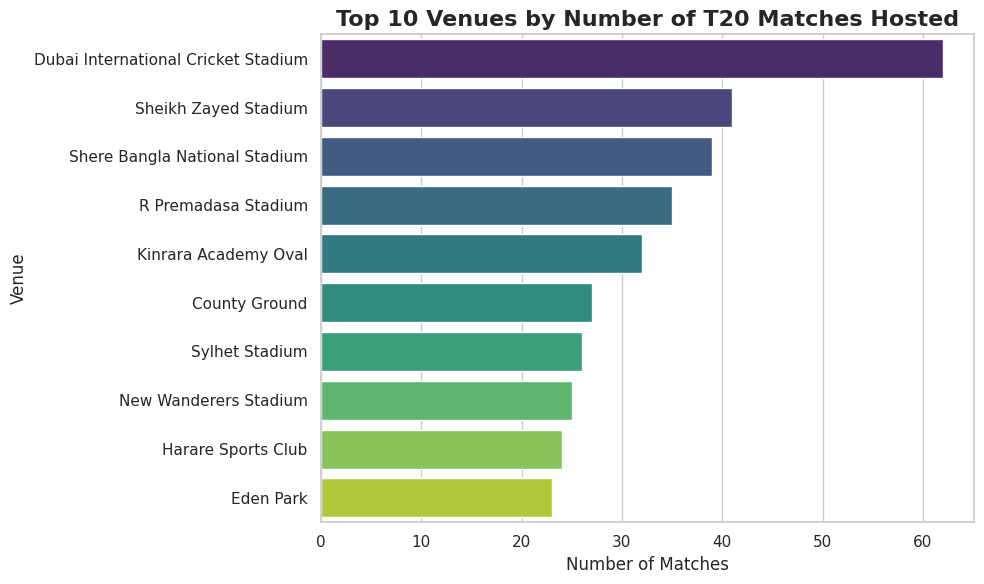

In [ ]:
plt.figure(figsize=(10, 6))

# Grab the top 10 venues instead of just 3
top_10_venues = df['venue'].value_counts().head(10)

# Create a horizontal barplot using Seaborn
sns.barplot(x=top_10_venues.values, y=top_10_venues.index, palette='viridis')

plt.title('Top 10 Venues by Number of T20 Matches Hosted', fontsize=16, fontweight='bold')
plt.xlabel('Number of Matches', fontsize=12)
plt.ylabel('Venue', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

## <u><b>Visualization 2: Top 10 Teams by Win Percentage (Vertical Bar Chart)</b></u>




/tmp/ipykernel_759/3730863692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_teams.index, y=top_10_teams.values, palette='mako')


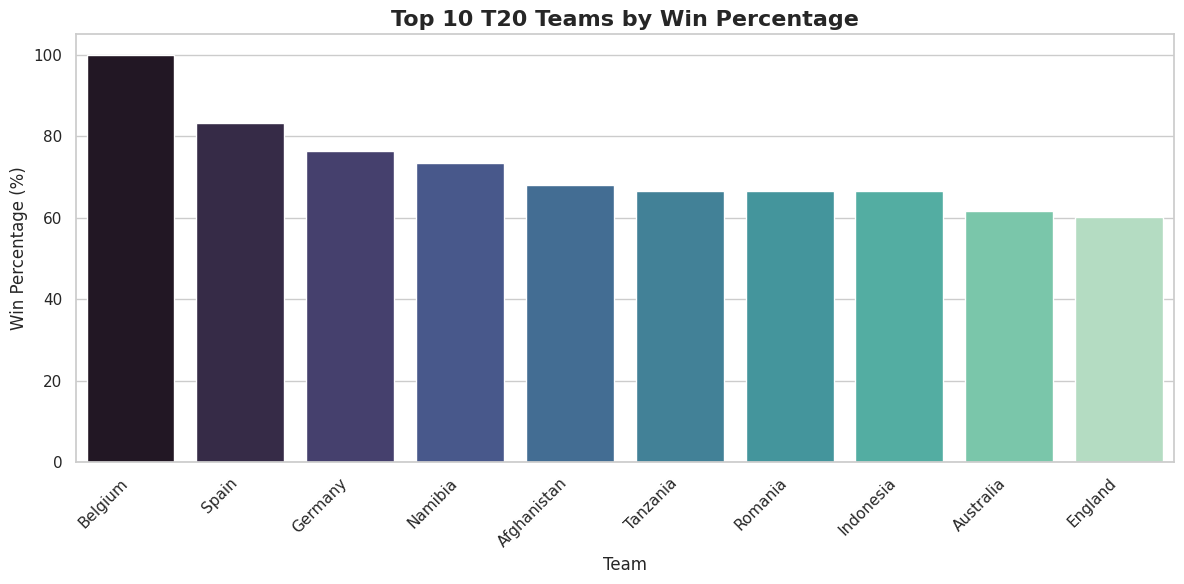

In [ ]:
plt.figure(figsize=(12, 6))

# Calculate top 10 teams from the win_percentage variable we made in Task 4
top_10_teams = win_percentage.dropna().sort_values(ascending=False).head(10)

# Create a vertical barplot
sns.barplot(x=top_10_teams.index, y=top_10_teams.values, palette='mako')

plt.title('Top 10 T20 Teams by Win Percentage', fontsize=16, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)

# Rotate the x-axis labels so the team names don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## <u><b>Visualization 3: Toss Decision (Pie Chart)</b></u>




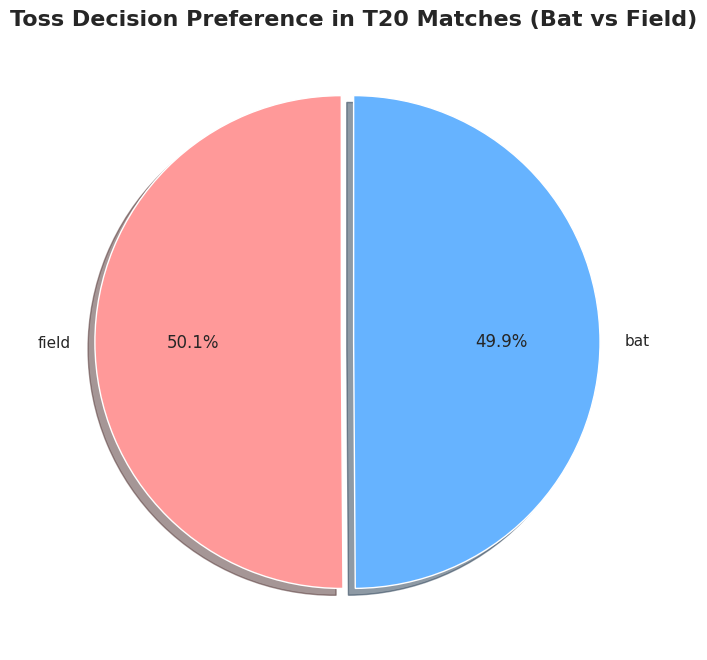

In [ ]:
plt.figure(figsize=(8, 8))

# Count how many times captains chose to bat vs field
toss_counts = df['toss_decision'].value_counts()

# Create a pie chart using Matplotlib
plt.pie(toss_counts.values, labels=toss_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#ff9999','#66b3ff'], explode=(0.05, 0), shadow=True)

plt.title('Toss Decision Preference in T20 Matches (Bat vs Field)', fontsize=16, fontweight='bold')

plt.show()